In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('student_dataset_10000_rows.csv')
print(df.shape)
df.head()

(10000, 8)


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


Numeric features: study_hours, attendance, sleep_hours, internet_usage, assignments_completed, previous_score

Nominal feature : placement_status (Placed / Not Placed)

Target          : exam_score

In [3]:
print(df.isnull().sum())

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


In [4]:
df_encoded = pd.get_dummies(df, columns=['placement_status'], drop_first=True)
df_encoded.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status_Placed
0,7,56,8,7,10,62,100.00,True
1,4,69,5,3,8,56,100.00,True
2,11,60,7,6,10,45,100.00,True
3,8,99,9,8,4,55,90.17,True
4,5,52,8,6,8,40,78.82,True


placement_status_Placed : 1 = Placed, 0 = Not Placed

In [5]:
X = df_encoded.drop('exam_score', axis=1)
y = df_encoded['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (8000, 7)  Test size: (2000, 7)


In [7]:
numeric_cols = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

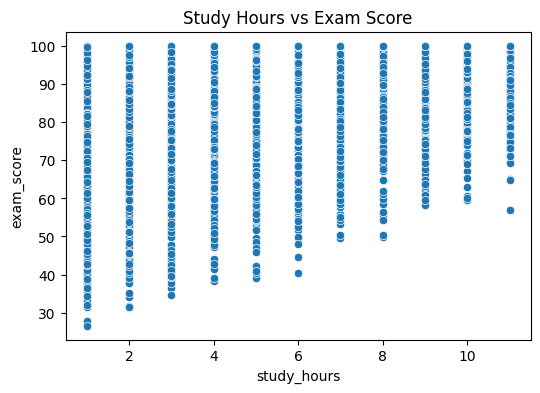

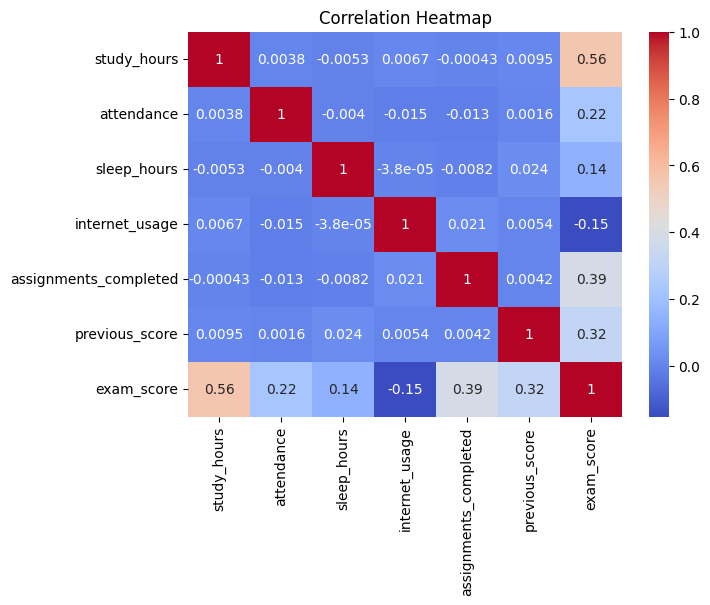

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['study_hours'], y=df['exam_score'])
plt.title('Study Hours vs Exam Score')
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols + ['exam_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Coefficients:")
for col, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"  {col}: {coef:.3f}")
print("Intercept:", model.intercept_)

Coefficients:
  study_hours: 5.565
  attendance: 2.132
  sleep_hours: 1.363
  internet_usage: -1.591
  assignments_completed: 3.870
  previous_score: 3.053
  placement_status_Placed: 19.426
Intercept: 70.48939040933948


In [10]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

--- Training Performance ---
MAE  : 5.282
MSE  : 42.959
RMSE : 6.554
R2   : 0.810

--- Testing Performance ---
MAE  : 5.149
MSE  : 41.767
RMSE : 6.463
R2   : 0.818

     Metric      Train       Test
0       MAE   5.282062   5.148666
1       MSE  42.958513  41.766980
2      RMSE   6.554274   6.462738
3  R2 Score   0.809888   0.818198


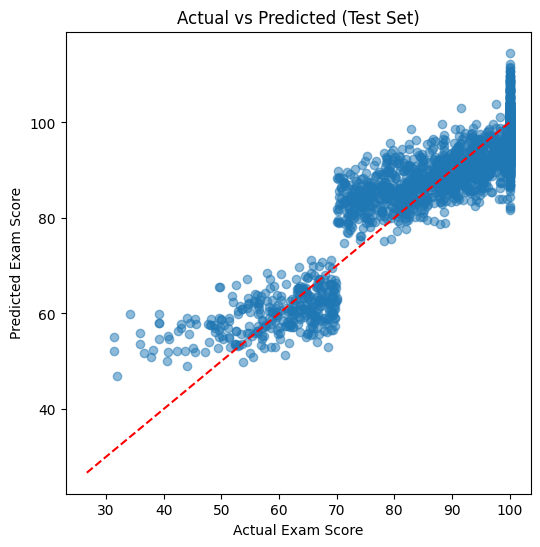

In [11]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.3f}\n")
    return mae, mse, rmse, r2

train_scores = evaluate(y_train, y_train_pred, "Training Performance")
test_scores = evaluate(y_test, y_test_pred, "Testing Performance")

results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Train': train_scores,
    'Test': test_scores
})
print(results)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted (Test Set)')
plt.show()

In [14]:
r2_gap = train_scores[3] - test_scores[3]
rmse_gap = test_scores[2] - train_scores[2]

print(f"R2 gap (Train - Test): {r2_gap:.3f}")
print(f"RMSE gap (Test - Train): {rmse_gap:.3f}")

if r2_gap < 0.05:
    print("Train and test performance are close, model is GENERALIZED, not overfitting.")
else:
    print("Noticeable gap between train and test, model may be OVERFITTING.")

# Cross-validation check
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
print("CV R2 scores:", np.round(cv_scores, 3))
print("Mean CV R2:", round(cv_scores.mean(), 3), " | Test R2:", round(test_scores[3], 3))

R2 gap (Train - Test): -0.008
RMSE gap (Test - Train): -0.092
Train and test performance are close, model is GENERALIZED, not overfitting.
CV R2 scores: [0.8   0.816 0.807 0.807 0.816]
Mean CV R2: 0.809  | Test R2: 0.818
